In [2]:
import os
import re
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import tensorflow as tf
from google.colab import drive

# Using NLTK stopwords
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Using contractions library for expansion
# Install with:  pip install contractions
!pip install contractions
import contractions

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, SimpleRNN, LSTM,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('All libraries imported successfully.')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
All libraries imported successfully.


In [3]:
# ============================================================
# PART 1.1: SEED AND DATA LOADING
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/AI Sem6/Coursework/Assignment3/Racist Sexist or Not Dataset/train_racisit.csv'
test_path  = '/content/drive/MyDrive/AI Sem6/Coursework/Assignment3/Racist Sexist or Not Dataset/test_racisit.csv'

df      = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

for frame in [df, test_df]:
    unnamed = [c for c in frame.columns if 'Unnamed' in c]
    frame.drop(columns=unnamed, inplace=True)

TEXT_COL  = 'tweet'
LABEL_COL = 'label'

df[TEXT_COL]      = df[TEXT_COL].fillna('')
test_df[TEXT_COL] = test_df[TEXT_COL].fillna('')

print('Train shape:', df.shape)
print('Test  shape:', test_df.shape)
df.head()

Mounted at /content/drive
Train shape: (31962, 3)
Test  shape: (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [4]:
# ============================================================
# PART 1.2: BASIC DATASET INFORMATION
# ============================================================

print('=' * 50)
print('DATASET INFORMATION')
print('=' * 50)
print('Shape         :', df.shape)
print('\nColumn Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDuplicate Rows :', df.duplicated().sum())
print('\nLabel Distribution:')
print(df[LABEL_COL].value_counts())
print('\nPercentage Distribution:')
print(df[LABEL_COL].value_counts(normalize=True).mul(100).round(2))

DATASET INFORMATION
Shape         : (31962, 3)

Column Types:
id        int64
label     int64
tweet    object
dtype: object

Missing Values:
id       0
label    0
tweet    0
dtype: int64

Duplicate Rows : 0

Label Distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Percentage Distribution:
label
0    92.99
1     7.01
Name: proportion, dtype: float64


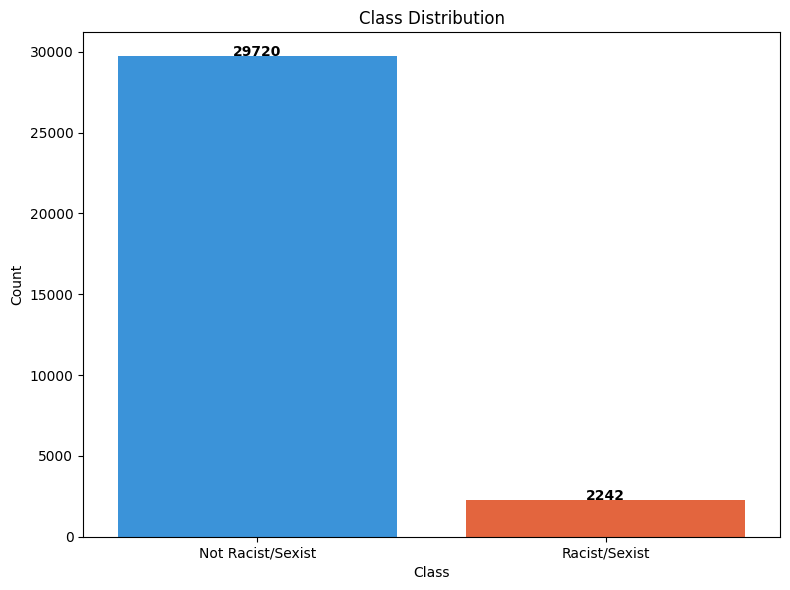

In [7]:
counts = df[LABEL_COL].value_counts()
class_names = ['Not Racist/Sexist', 'Racist/Sexist']

plt.figure(figsize=(8, 6))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=['#2196F3', '#FF5722'], legend=False)
plt.xticks(ticks=[0, 1], labels=class_names, rotation=0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')

for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

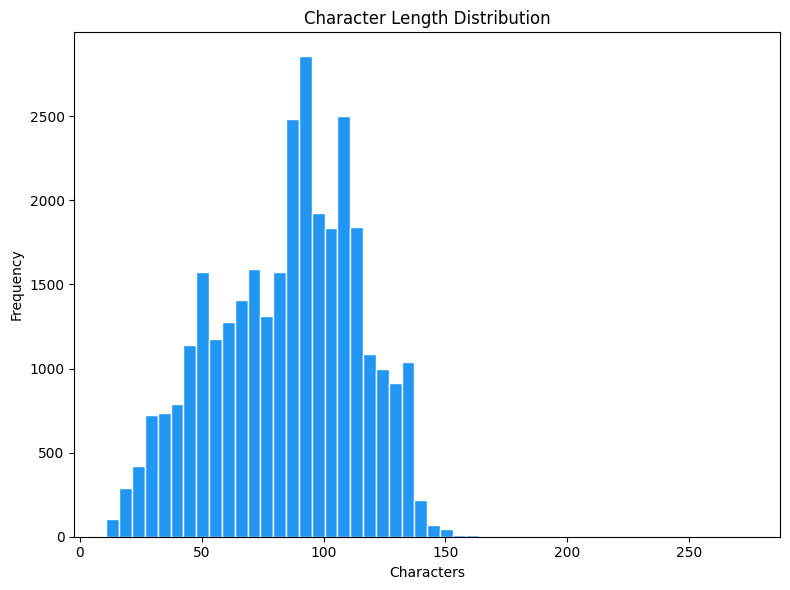

           char_len   word_count
count  31962.000000  31962.00000
mean      84.739628     13.15872
std       29.455749      5.47815
min       11.000000      3.00000
25%       63.000000      9.00000
50%       88.000000     13.00000
75%      108.000000     17.00000
max      274.000000     34.00000


In [9]:
df['char_len']   = df[TEXT_COL].apply(len)
df['word_count'] = df[TEXT_COL].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 6))
plt.hist(df['char_len'], bins=50, color='#2196F3', edgecolor='white')
plt.title('Character Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(df[['char_len', 'word_count']].describe())

In [10]:
# ============================================================
# PART 1.5: TEXT CLEANING FUNCTION
# ============================================================

lemmatizer  = WordNetLemmatizer()

nltk_stops    = set(stopwords.words('english'))
negation_keep = {'no', 'not', 'never', 'nor', 'neither',
                 'nobody', 'nothing', 'nowhere', 'hardly', 'barely'}
noise_words   = {'amp', 'rt', 'via', 'im', 'ur', 'u', 'bc', 'lol'}
stop_words    = (nltk_stops - negation_keep) | noise_words


def clean_text(text: str) -> str:
    # 1. Lowercase
    text = str(text).lower()

    # 2. Expand contractions using library
    text = contractions.fix(text)

    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 4. Remove @mentions
    text = re.sub(r'@\w+', ' ', text)

    # 5. Strip # symbol but keep the hashtag word
    text = re.sub(r'#(\w+)', r'\1', text)

    # 6. Remove digits
    text = re.sub(r'\d+', ' ', text)

    # 7. Remove punctuation via regex
    text = re.sub(r'[^\w\s]', ' ', text)

    # 8. Strip non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 9. Tokenise, remove stopwords, lemmatize
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in text.split()
        if tok not in stop_words and len(tok) > 1
    ]

    return ' '.join(tokens)


print('clean_text function ready.')

clean_text function ready.


In [11]:
# ============================================================
# PART 1.6: APPLY CLEANING
# ============================================================

df['clean_tweet']      = df[TEXT_COL].apply(clean_text)
test_df['clean_tweet'] = test_df[TEXT_COL].apply(clean_text)

print('Sample before / after cleaning:')
for i in range(3):
    print(f'\n[{i}] Original : {df[TEXT_COL].iloc[i]}')
    print(f'Cleaned : {df["clean_tweet"].iloc[i]}')

empty_idx = df[df['clean_tweet'].str.strip() == ''].index
print(f'\nDropping {len(empty_idx)} empty rows after cleaning.')
df.drop(index=empty_idx, inplace=True)
df.reset_index(drop=True, inplace=True)

df[[TEXT_COL, 'clean_tweet', LABEL_COL]].head()

Sample before / after cleaning:

[0] Original :  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
    Cleaned  : father dysfunctional selfish drag kid dysfunction run

[1] Original : @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
    Cleaned  : thanks lyft credit cannot use not offer wheelchair van pdx disapointed getthanked

[2] Original :   bihday your majesty
    Cleaned  : bihday majesty

Dropping 37 empty rows after cleaning.


,tweet,clean_tweet,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cannot use not offer wheelc...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love take time,0
4,factsguide: society now #motivation,factsguide society motivation,0


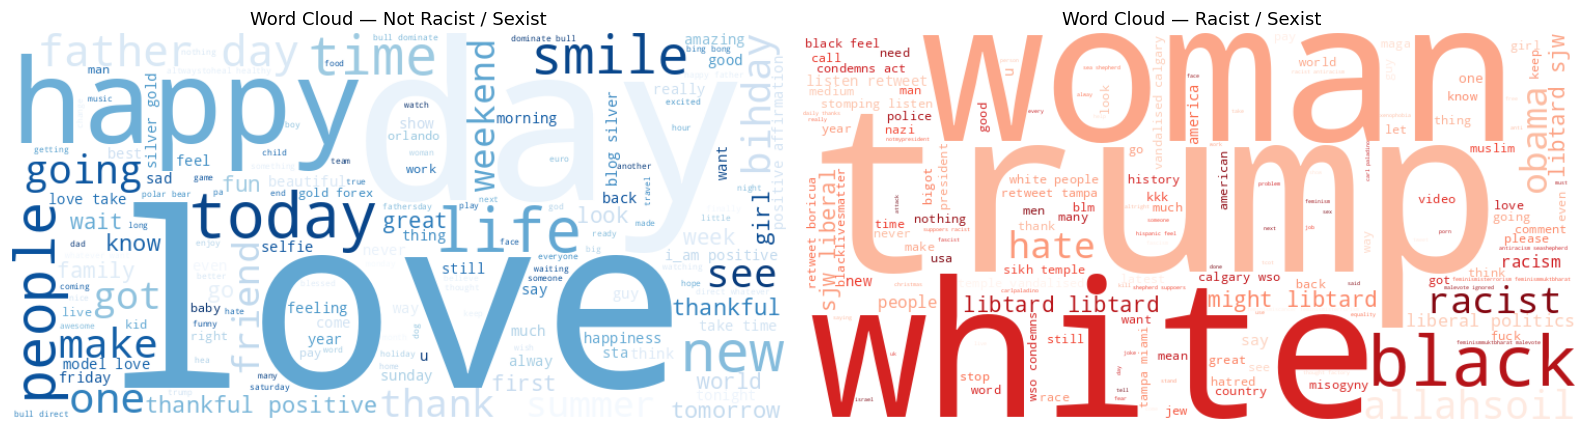

In [12]:
# ============================================================
# PART 1.7: WORD CLOUD — ONE PER CLASS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (lv, lname, cmap) in enumerate([
    (0, 'Not Racist / Sexist', 'Blues'),
    (1, 'Racist / Sexist',     'Reds')
]):
    corpus = ' '.join(df[df[LABEL_COL] == lv]['clean_tweet'])
    wc = WordCloud(
        width=750, height=375,
        background_color='white',
        max_words=150,
        colormap=cmap
    ).generate(corpus)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Word Cloud — {lname}', fontsize=13)

plt.tight_layout()
plt.show()

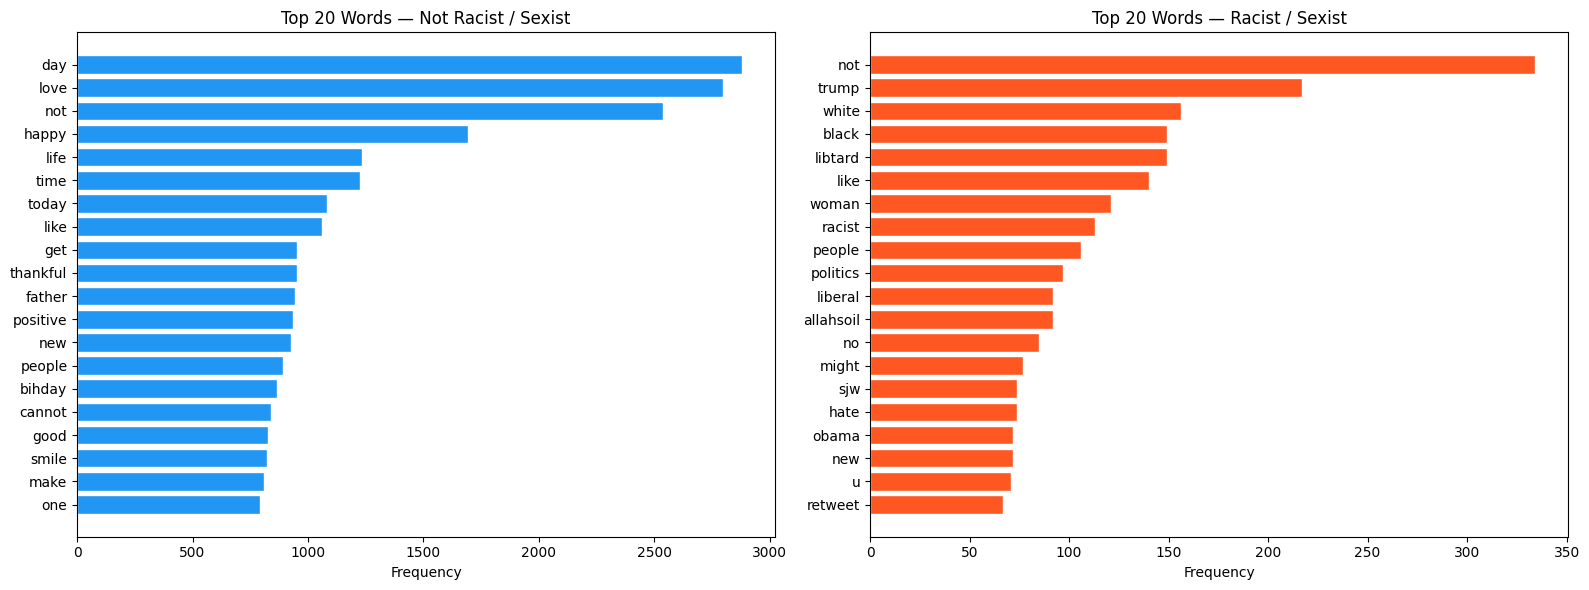

In [13]:
# ============================================================
# PART 1.8: TOP 20 WORDS — SPLIT BY CLASS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (lv, lname, color) in enumerate([
    (0, 'Not Racist / Sexist', '#2196F3'),
    (1, 'Racist / Sexist',     '#FF5722')
]):
    corpus = ' '.join(df[df[LABEL_COL] == lv]['clean_tweet'])
    top20  = dict(Counter(corpus.split()).most_common(20))
    words  = list(top20.keys())[::-1]
    freqs  = list(top20.values())[::-1]

    axes[idx].barh(words, freqs, color=color, edgecolor='white')
    axes[idx].set_title(f'Top 20 Words — {lname}')
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# PART 2.1: TRAIN / VALIDATION SPLIT  (80 / 20, STRATIFIED)
# ============================================================

X = df['clean_tweet'].values
y = df[LABEL_COL].astype(int).values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print('Train samples :', len(X_train))
print('Val   samples :', len(X_val))
print('Train label dist:', Counter(y_train))
print('Val   label dist:', Counter(y_val))

Train samples : 25540
Val   samples : 6385
Train label dist: Counter({np.int64(0): 23749, np.int64(1): 1791})
Val   label dist: Counter({np.int64(0): 5937, np.int64(1): 448})


In [15]:
# ============================================================
# PART 2.2: CLASS IMBALANCE — CLASS WEIGHTS
# ============================================================

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

print('Class weights:', class_weight)

Class weights: {np.int64(0): np.float64(0.5377068508147711), np.int64(1): np.float64(7.130094919039642)}


In [16]:
# ============================================================
# PART 2.3: TOKENISATION AND SEQUENCE PADDING
# ============================================================

MAX_WORDS = 10000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # fit on training data only — no leakage

train_seqs = tokenizer.texts_to_sequences(X_train)
val_seqs   = tokenizer.texts_to_sequences(X_val)
test_seqs  = tokenizer.texts_to_sequences(test_df['clean_tweet'])

# 90th-percentile padding length
MAX_LEN = int(np.percentile([len(s) for s in train_seqs if len(s) > 0], 90))
MAX_LEN = max(MAX_LEN, 5)
print('MAX_LEN:', MAX_LEN)

# Pre-padding: zeros at the START of each sequence
X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='pre', truncating='post')
X_val_pad   = pad_sequences(val_seqs,   maxlen=MAX_LEN, padding='pre', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='pre', truncating='post')

y_train = np.array(y_train).astype('int32')
y_val   = np.array(y_val).astype('int32')

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print('Vocab size   :', vocab_size)
print('X_train_pad  :', X_train_pad.shape)
print('X_val_pad    :', X_val_pad.shape)

MAX_LEN: 12
Vocab size   : 10000
X_train_pad  : (25540, 12)
X_val_pad    : (6385, 12)


In [17]:
# ============================================================
# PART 2.4: SAVE TOKENISER AND MAX_LEN
# ============================================================

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('max_len.pkl', 'wb') as f:
    pickle.dump(MAX_LEN, f)

print('Tokeniser and MAX_LEN saved.')

Tokeniser and MAX_LEN saved.


In [18]:
# ============================================================
# PART 2.5: SHARED TRAINING SETTINGS
# ============================================================

EMBEDDING_DIM = 100
EPOCHS        = 20
BATCH_SIZE    = 32


def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss', patience=5,
            min_delta=0.001, restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=3, min_lr=1e-7, verbose=1
        )
    ]

In [19]:
# ============================================================
# PART 2.6: MODEL 1 — SIMPLE RNN
# ============================================================

model1 = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),

    SimpleRNN(units=64, dropout=0.3, recurrent_dropout=0.2),

    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
], name='SimpleRNN_Model')

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,625 (2.48 MB)

 Trainable params: 650,497 (2.48 MB)

 Non-trainable params: 128 (512.00 B)

In [20]:
# ============================================================
# PART 2.7: MODEL 2 — LSTM WITH TRAINABLE EMBEDDING
# ============================================================

model2 = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),

    LSTM(units=64, dropout=0.3, recurrent_dropout=0.2),

    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
], name='LSTM_Model')

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,393 (2.58 MB)

 Trainable params: 675,265 (2.58 MB)

 Non-trainable params: 128 (512.00 B)

In [21]:
# ============================================================
# PART 2.8: LOAD GLOVE EMBEDDINGS FOR MODEL 3
# ============================================================

!pip install -q gensim
import gensim.downloader as gensim_api

print('Loading GloVe embeddings...')
word_vectors = gensim_api.load('glove-wiki-gigaword-100')

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
covered = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in word_vectors:
        embedding_matrix[idx] = word_vectors[word]
        covered += 1

coverage = covered / min(vocab_size - 1, len(tokenizer.word_index)) * 100
print(f'Words covered : {covered}')
print(f'GloVe coverage: {coverage:.2f} %')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.4 MB/s eta 0:00:00
Loading GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Words covered : 8129
GloVe coverage: 81.30 %


In [30]:
# ============================================================
# PART 2.9: MODEL 3 — LSTM WITH GLOVE EMBEDDINGS
# ============================================================

model3 = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=True
    ),

    LSTM(units=64, dropout=0.3, recurrent_dropout=0.2),

    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
], name='LSTM_GloVe_Model')

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 12, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,609 (3.98 MB)

 Trainable params: 1,044,481 (3.98 MB)

 Non-trainable params: 128 (512.00 B)

In [31]:
# ============================================================
# PART 2.10: MODEL OVERVIEW TABLE
# ============================================================

overview = pd.DataFrame({
    'Model'      : ['Model 1', 'Model 2', 'Model 3'],
    'Name'       : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Embedding'  : ['Trainable (random)', 'Trainable (random)', 'Pretrained GloVe'],
    'Norm Layer' : ['BatchNormalization', 'BatchNormalization', 'BatchNormalization'],
    'Parameters' : [model1.count_params(), model2.count_params(), model3.count_params()]
})
print(overview.to_string(index=False))

  Model         Name          Embedding         Norm Layer  Parameters
Model 1   Simple RNN Trainable (random) BatchNormalization      650625
Model 2         LSTM Trainable (random) BatchNormalization      675393
Model 3 LSTM + GloVe   Pretrained GloVe BatchNormalization     1044609


In [24]:
# ============================================================
# PART 3.1: LEARNING CURVE HELPER
# ============================================================

def plot_learning_curves(history, model_name):
    ep = range(1, len(history.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(ep, history.history['accuracy'],     label='Train', color='steelblue')
    axes[0].plot(ep, history.history['val_accuracy'], label='Val',   color='tomato', linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(ep, history.history['loss'],     label='Train', color='steelblue')
    axes[1].plot(ep, history.history['val_loss'], label='Val',   color='tomato', linestyle='--')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [25]:
# ============================================================
# PART 3.2: CONFUSION MATRIX HELPER
# ============================================================

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Not R/S', 'Racist/Sexist'],
        yticklabels=['Not R/S', 'Racist/Sexist']
    )
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [26]:
# ============================================================
# PART 3.3: EVALUATION FUNCTION — FIXED 0.5 THRESHOLD
# ============================================================

results_store = []


def evaluate_model(model, model_name):
    y_prob = model.predict(X_val_pad).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    print('\n' + '=' * 55)
    print(f' {model_name}')
    print('=' * 55)
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1 Score  : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(
        y_val, y_pred,
        target_names=['Not Racist/Sexist', 'Racist/Sexist'],
        zero_division=0
    ))

    cm = confusion_matrix(y_val, y_pred)
    plot_confusion_matrix(cm, f'{model_name} — Confusion Matrix')

    results_store.append({
        'Model': model_name,
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec,   'F1 Score': f1
    })

    return acc, prec, rec, f1

Training Model 1: Simple RNN
Epoch 1/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.6040 - loss: 0.6189 - val_accuracy: 0.8413 - val_loss: 0.3347 - learning_rate: 0.0010
Epoch 2/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8316 - loss: 0.3296 - val_accuracy: 0.8850 - val_loss: 0.2618 - learning_rate: 0.0010
Epoch 3/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9046 - loss: 0.2320 - val_accuracy: 0.8982 - val_loss: 0.2585 - learning_rate: 0.0010
Epoch 4/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9363 - loss: 0.1498 - val_accuracy: 0.9139 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 5/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9529 - loss: 0.1177 - val_accuracy: 0.9258 - val_loss: 0.2499 - learning_rate: 0.0010
Epoch 6/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9616 - loss: 0.0987 - val_accuracy: 0.9367 - val_loss: 0.2367 - learning_rate: 0.0010
Epoch 7/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 12s 15m

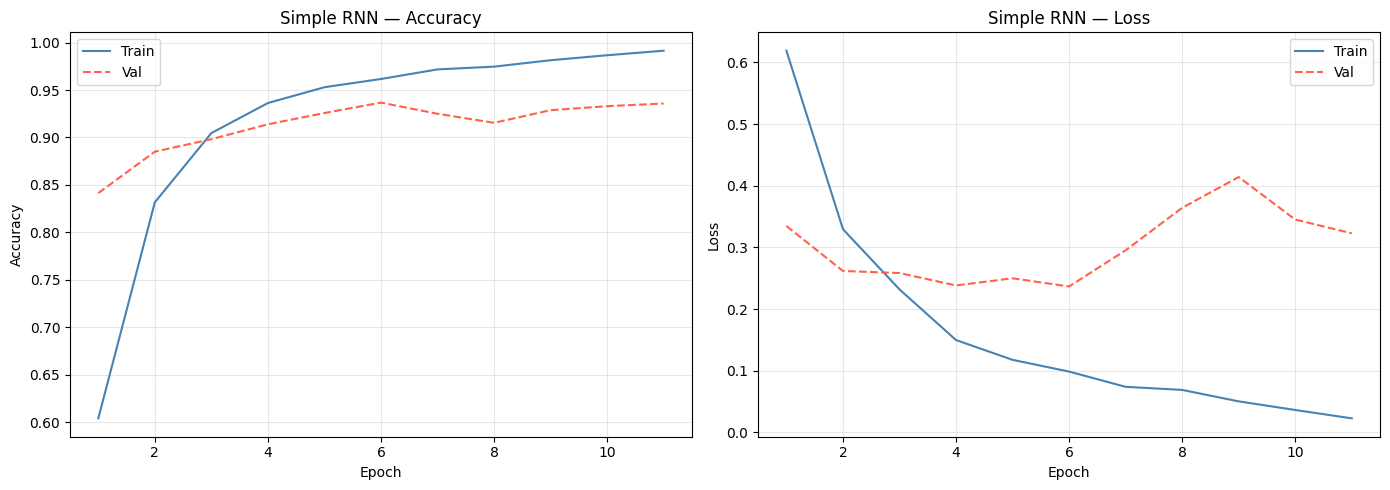

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

 Simple RNN
Accuracy  : 0.9367
Precision : 0.5383
Recall    : 0.6897
F1 Score  : 0.6047

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist       0.98      0.96      0.97      5937
    Racist/Sexist       0.54      0.69      0.60       448

         accuracy                           0.94      6385
        macro avg       0.76      0.82      0.79      6385
     weighted avg       0.95      0.94      0.94      6385



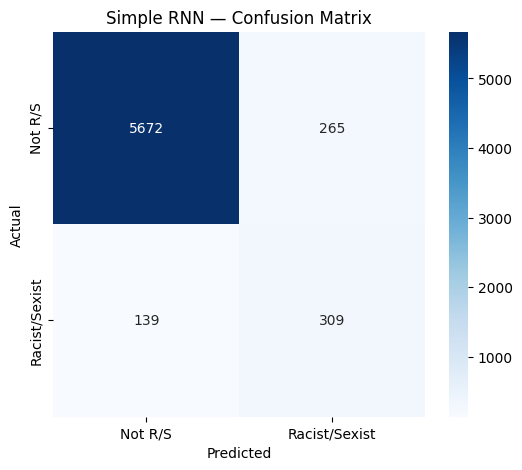

In [27]:
# ============================================================
# PART 3.4: TRAIN MODEL 1 — SIMPLE RNN
# ============================================================

print('Training Model 1: Simple RNN')

history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weight,
    verbose=1
)

plot_learning_curves(history1, 'Simple RNN')
acc1, prec1, rec1, f1_1 = evaluate_model(model1, 'Simple RNN')

Training Model 2: LSTM
Epoch 1/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7561 - loss: 0.4202 - val_accuracy: 0.8799 - val_loss: 0.2751 - learning_rate: 0.0010
Epoch 2/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9091 - loss: 0.2202 - val_accuracy: 0.8985 - val_loss: 0.2705 - learning_rate: 0.0010
Epoch 3/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9498 - loss: 0.1358 - val_accuracy: 0.9190 - val_loss: 0.2702 - learning_rate: 0.0010
Epoch 4/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9639 - loss: 0.0987 - val_accuracy: 0.9283 - val_loss: 0.2731 - learning_rate: 0.0010
Epoch 5/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9664 - loss: 0.0916 - val_accuracy: 0.9218 - val_loss: 0.3197 - learning_rate: 0.0010
Epoch 6/20
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9702 - loss: 0.0747
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
799/799 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step -

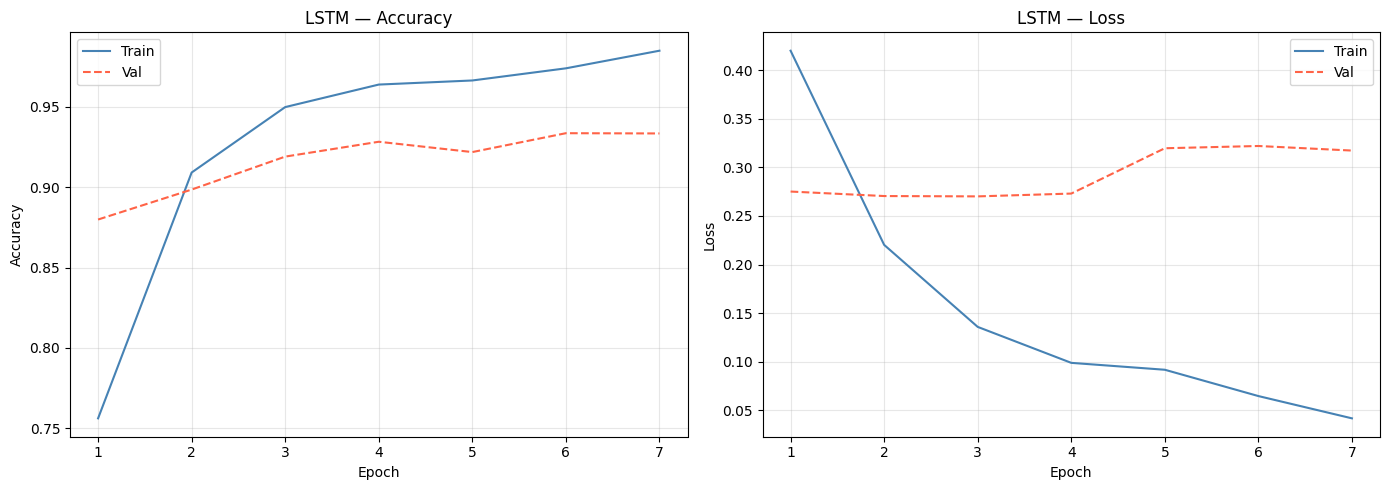

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

 LSTM
Accuracy  : 0.8985
Precision : 0.3927
Recall    : 0.8170
F1 Score  : 0.5304

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist       0.98      0.90      0.94      5937
    Racist/Sexist       0.39      0.82      0.53       448

         accuracy                           0.90      6385
        macro avg       0.69      0.86      0.74      6385
     weighted avg       0.94      0.90      0.91      6385



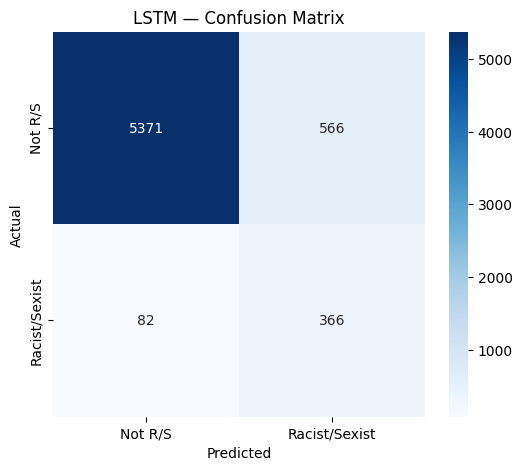

In [28]:
# ============================================================
# PART 3.5: TRAIN MODEL 2 — LSTM
# ============================================================

print('Training Model 2: LSTM')

history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weight,
    verbose=1
)

plot_learning_curves(history2, 'LSTM')
acc2, prec2, rec2, f1_2 = evaluate_model(model2, 'LSTM')

Training Model 3: LSTM with GloVe
Epoch 1/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.7396 - loss: 0.5036 - val_accuracy: 0.8662 - val_loss: 0.3049 - learning_rate: 0.0010
Epoch 2/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.8489 - loss: 0.3193 - val_accuracy: 0.8966 - val_loss: 0.2472 - learning_rate: 0.0010
Epoch 3/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.8921 - loss: 0.2414 - val_accuracy: 0.8968 - val_loss: 0.2426 - learning_rate: 0.0010
Epoch 4/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9200 - loss: 0.1722 - val_accuracy: 0.9372 - val_loss: 0.1782 - learning_rate: 0.0010
Epoch 5/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9426 - loss: 0.1358 - val_accuracy: 0.9295 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 6/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9525 - loss: 0.1138 - val_accuracy: 0.9244 - val_loss: 0.2302 - learning_rate: 0.0010
Epoch 7/20
797/799 ━━━━━━━━━━━━━━━━━━━━ 0s

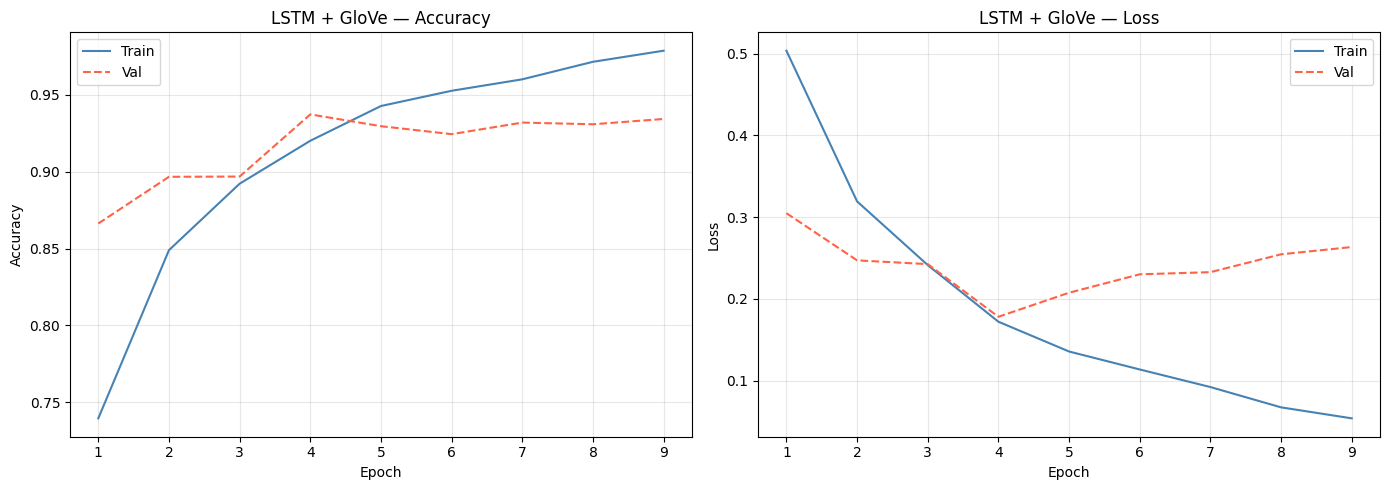

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

 LSTM + GloVe
Accuracy  : 0.9372
Precision : 0.5361
Recall    : 0.7790
F1 Score  : 0.6351

Classification Report:
                   precision    recall  f1-score   support

Not Racist/Sexist       0.98      0.95      0.97      5937
    Racist/Sexist       0.54      0.78      0.64       448

         accuracy                           0.94      6385
        macro avg       0.76      0.86      0.80      6385
     weighted avg       0.95      0.94      0.94      6385



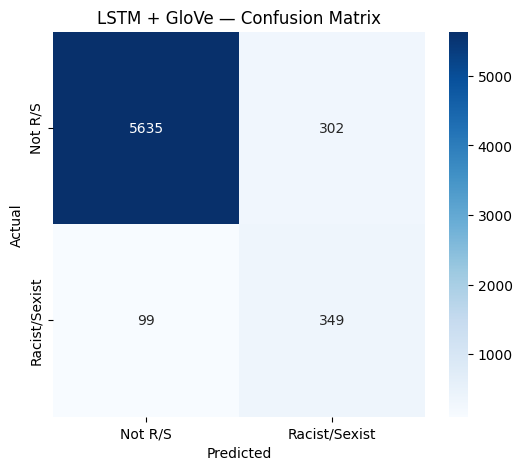

In [32]:
# ============================================================
# PART 3.6: TRAIN MODEL 3 — LSTM + GLOVE
# ============================================================

print('Training Model 3: LSTM with GloVe')

history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weight,
    verbose=1
)

plot_learning_curves(history3, 'LSTM + GloVe')
acc3, prec3, rec3, f1_3 = evaluate_model(model3, 'LSTM + GloVe')

       Model  Accuracy  Precision   Recall  F1 Score
LSTM + GloVe  0.937197   0.536098 0.779018  0.635123
  Simple RNN  0.936727   0.538328 0.689732  0.604697
        LSTM  0.898512   0.392704 0.816964  0.530435


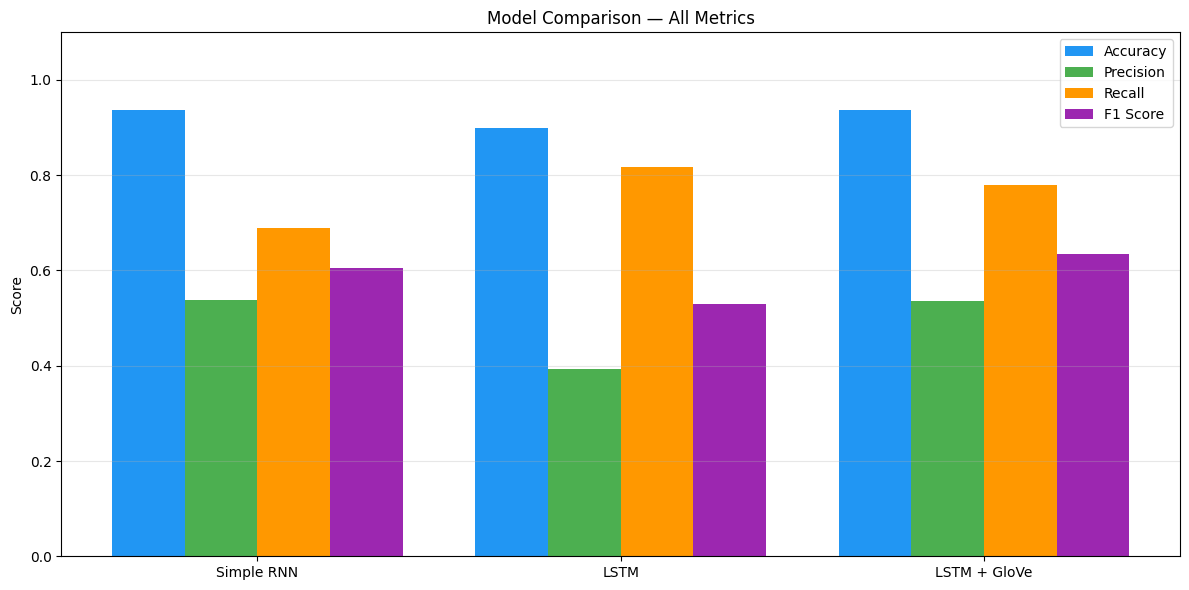

In [34]:
# ============================================================
# PART 3.7: COMPARE ALL MODELS
# ============================================================

model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
results_df  = pd.DataFrame(results_store)

# Drop duplicates based on 'Model', keeping the last recorded result for each model
results_df = results_df.drop_duplicates(subset=['Model'], keep='last')

print(results_df.sort_values('F1 Score', ascending=False).to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x       = np.arange(len(model_names))
width   = 0.2
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    # Ensure that the selection from results_df matches model_names
    vals = results_df.set_index('Model').loc[model_names, metric].values
    ax.bar(x + i * width, vals, width, label=metric, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — All Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# PART 3.8: SELECT AND SAVE BEST MODEL
# ============================================================

f1_scores  = [f1_1, f1_2, f1_3]
best_idx   = int(np.argmax(f1_scores))
best_model = [model1, model2, model3][best_idx]
best_name  = model_names[best_idx]

print(f'Best model : {best_name}  (F1 = {f1_scores[best_idx]:.4f})')

best_model.save('best_model.keras')
print('Saved best_model.keras')

Best model : LSTM + GloVe  (F1 = 0.6351)
Saved best_model.keras


In [36]:
# ============================================================
# PART 3.9: TEST SET PREDICTIONS
# ============================================================

test_prob = best_model.predict(X_test_pad).ravel()
test_pred = (test_prob >= 0.5).astype(int)

test_df['probability']     = test_prob
test_df['predicted_label'] = test_pred

test_df[['tweet', 'clean_tweet', 'probability', 'predicted_label']].head(10)

538/538 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step


,tweet,clean_tweet,probability,predicted_label
0,#studiolife #aislife #requires #passion #dedic...,studiolife aislife requires passion dedication...,0.000893,0
1,@user #white #supremacists want everyone to s...,white supremacist want everyone see new bird m...,0.649965,1
2,safe ways to heal your #acne!! #altwaystohe...,safe way heal acne altwaystoheal healthy healing,0.000146,0
3,is the hp and the cursed child book up for res...,hp cursed child book reservation already yes n...,0.001359,0
4,"3rd #bihday to my amazing, hilarious #nephew...",rd bihday amazing hilarious nephew eli ahmir u...,0.000018,0
5,choose to be :) #momtips,choose momtips,0.190821,0
6,something inside me dies ð¦ð¿â¨ eyes nes...,something inside dy eye ness smokeyeyes tired ...,0.000145,0
7,#finished#tattoo#inked#ink#loveitâ¤ï¸ #â¤ï¸...,finishedtattooinkedinkloveit thanksaleeee,0.031398,0
8,@user @user @user i will never understand why...,never understand dad left young deep inthefeels,0.002813,0
9,#delicious #food #lovelife #capetown mannaep...,delicious food lovelife capetown mannaepicure ...,0.000547,0


In [37]:
# ============================================================
# PART 4.1: ERROR ANALYSIS — COLLECT MISCLASSIFIED EXAMPLES
# ============================================================

val_prob = best_model.predict(X_val_pad).ravel()
val_pred = (val_prob >= 0.5).astype(int)

error_df = pd.DataFrame({
    'original_text': X_val,
    'true_label'   : y_val,
    'pred_label'   : val_pred,
    'probability'  : val_prob
})

errors = error_df[error_df['true_label'] != error_df['pred_label']].reset_index(drop=True)

total_errors = len(errors)
error_rate   = total_errors / len(error_df) * 100

fp = errors[errors['pred_label'] == 1]  # predicted racist — actually not
fn = errors[errors['pred_label'] == 0]  # predicted safe  — actually racist

print(f'Total misclassifications : {total_errors} / {len(error_df)}  ({error_rate:.2f}%)')
print(f'False Positives (FP)     : {len(fp)}')
print(f'False Negatives (FN)     : {len(fn)}')

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Total misclassifications : 401 / 6385  (6.28%)
False Positives (FP)     : 302
False Negatives (FN)     : 99


In [38]:
# ============================================================
# PART 4.2: SHOW 3 EXAMPLE MISCLASSIFICATIONS
# ============================================================

label_map = {0: 'Not Racist/Sexist', 1: 'Racist/Sexist'}

sample_errors = errors.sample(min(3, len(errors)), random_state=SEED)

for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    etype = 'False Positive' if row['pred_label'] == 1 else 'False Negative'
    print(f'\n--- Misclassified Example {i} ({etype}) ---')
    print(f'Text       : {row["original_text"]}')
    print(f'True Label : {label_map[row["true_label"]]}')
    print(f'Predicted  : {label_map[row["pred_label"]]}')
    print(f'Probability: {row["probability"]:.4f}')


--- Misclassified Example 1 (False Positive) ---
Text       : tragedy happens express grief day later go back usual way hate racism
True Label : Not Racist/Sexist
Predicted  : Racist/Sexist
Probability: 0.6760

--- Misclassified Example 2 (False Positive) ---
Text       : kevin judged challenge
True Label : Not Racist/Sexist
Predicted  : Racist/Sexist
Probability: 0.8949

--- Misclassified Example 3 (False Positive) ---
Text       : huge blow considering content statement alleged constitute incitement
True Label : Not Racist/Sexist
Predicted  : Racist/Sexist
Probability: 0.7312


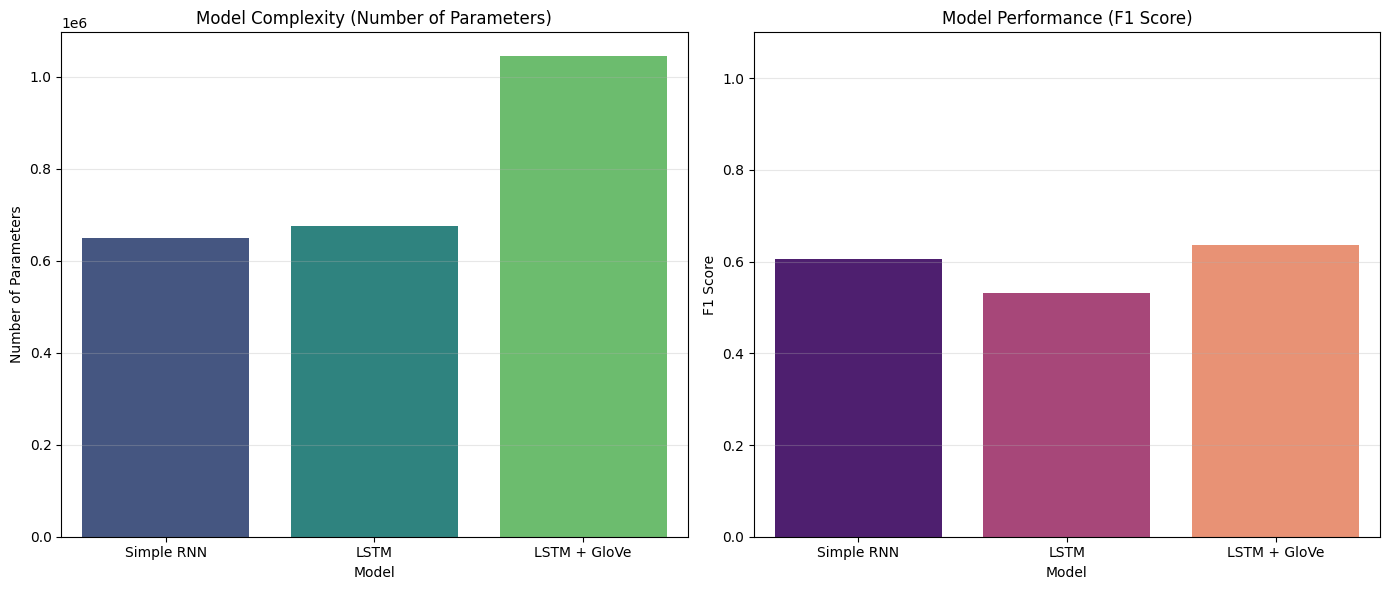

       Model  Parameters  F1 Score
  Simple RNN      650625  0.604697
        LSTM      675393  0.530435
LSTM + GloVe     1044609  0.635123


In [40]:
# ============================================================
# PART 4.3: MODEL COMPLEXITY vs PERFORMANCE BAR CHARTS
# ============================================================

complexity_df = pd.DataFrame({
    'Model'     : model_names,
    'Parameters': [model1.count_params(), model2.count_params(), model3.count_params()],
    'F1 Score'  : f1_scores
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for Number of Parameters
sns.barplot(x='Model', y='Parameters', data=complexity_df, palette='viridis', ax=axes[0], hue='Model', legend=False)
axes[0].set_title('Model Complexity (Number of Parameters)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Number of Parameters')
axes[0].grid(axis='y', alpha=0.3)

# Bar chart for F1 Score
sns.barplot(x='Model', y='F1 Score', data=complexity_df, palette='magma', ax=axes[1], hue='Model', legend=False)
axes[1].set_title('Model Performance (F1 Score)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.1) # Set y-limit to match other score plots
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(complexity_df.to_string(index=False))

In [41]:
# ============================================================
# PART 5.1: GRADIO GUI — SETUP
# ============================================================

!pip install -q gradio
import gradio as gr

loaded_model = tf.keras.models.load_model('best_model.keras', compile=False)

with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)

with open('max_len.pkl', 'rb') as f:
    loaded_max_len = pickle.load(f)

print('Model and assets loaded.')


def predict_tweet(text):
    if not text.strip():
        return {'Not Racist/Sexist': 0.5, 'Racist/Sexist': 0.5}, 'No input provided.'

    cleaned = clean_text(text)
    seq     = loaded_tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(
        seq, maxlen=loaded_max_len,
        padding='pre', truncating='post'
    )
    prob = float(loaded_model.predict(padded, verbose=0)[0][0])

    scores       = {'Not Racist/Sexist': round(1 - prob, 4),
                    'Racist/Sexist'    : round(prob, 4)}
    cleaned_info = f'Cleaned input: "{cleaned}"'
    return scores, cleaned_info

Model and assets loaded.


In [43]:
# ============================================================
# PART 5.2: BUILD AND LAUNCH GRADIO APP
# ============================================================

with gr.Blocks(title='Tweet Sentiment Classifier') as app:

    gr.Markdown('# Tweet Sentiment Classifier')
    gr.Markdown('Classify a tweet as **Racist / Sexist** or **Not Racist / Sexist**.')

    with gr.Tabs():

        with gr.Tab('Predict'):
            tweet_input = gr.Textbox(
                label='Enter Tweet',
                placeholder='Type a tweet here...',
                lines=4
            )
            predict_btn = gr.Button('Classify', variant='primary')

            with gr.Row():
                # gr.Label shows a confidence bar chart (friend used 3 Textboxes)
                confidence_out = gr.Label(label='Confidence Scores', num_top_classes=2)
                cleaned_out    = gr.Textbox(label='Preprocessed Input', interactive=False)

            predict_btn.click(
                fn=predict_tweet,
                inputs=tweet_input,
                outputs=[confidence_out, cleaned_out]
            )

            gr.Examples(
                examples=[
                    ['Have a wonderful day everyone!'],
                    ['I hate those people, they are disgusting.'],
                    ['The conference was incredibly productive today.'],
                    ['Women should not be allowed to vote.']
                ],
                inputs=tweet_input
            )


app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4ba87d52fc3f36d9e7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
